# Task 3: Classification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Data Loading and Binary Target Creation

In [2]:
df = pd.read_csv('faang_stock_prices.csv')
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

df['Price_Up'] = (df['Next_Day_Close'] > df['Close']).astype(int)

df['Price_Range'] = df['High'] - df['Low']
df['Price_Range_Pct'] = (df['High'] - df['Low']) / df['Close'] * 100
df['SMA_Crossover'] = df['SMA_7'] - df['SMA_21']
df['Bollinger_Width'] = df['Bollinger_Upper'] - df['Bollinger_Lower']
df['MACD_Histogram'] = df['MACD'] - df['MACD_Signal']

df = df.dropna()
print(f"Dataset shape: {df.shape}")
print(f"\nTarget variable 'Price_Up' distribution:")
print(df['Price_Up'].value_counts())
print(f"\nClass balance: {df['Price_Up'].mean()*100:.2f}% up days")

Dataset shape: (14964, 25)

Target variable 'Price_Up' distribution:
Price_Up
1    8034
0    6930
Name: count, dtype: int64

Class balance: 53.69% up days


## 2. Class Balance Analysis

Class ratio (minority/majority): 0.8626


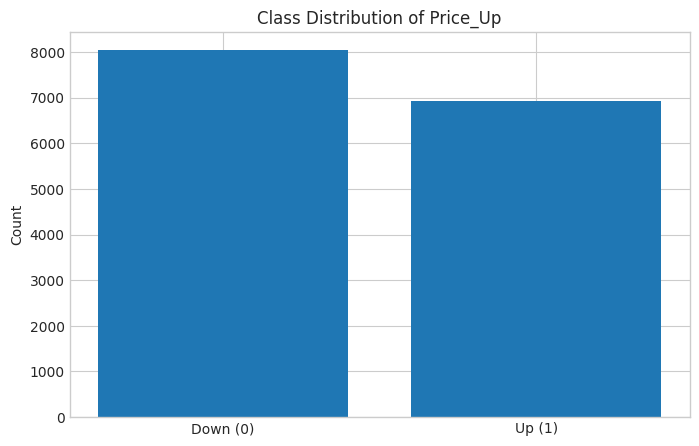

In [3]:
class_counts = df['Price_Up'].value_counts()
balance_ratio = class_counts.min() / class_counts.max()
print(f"Class ratio (minority/majority): {balance_ratio:.4f}")

plt.figure(figsize=(8, 5))
plt.bar(['Down (0)', 'Up (1)'], class_counts.values)
plt.ylabel('Count')
plt.title('Class Distribution of Price_Up')
plt.show()

## 3. DIY Logistic Regression with Gradient Descent

In [4]:
class LogisticRegressionGD:
    def __init__(self, learning_rate=0.01, n_iterations=1000, class_weight=None):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.class_weight = class_weight
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def _compute_loss(self, y_true, y_pred):
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.loss_history = []

        for _ in range(self.n_iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self._sigmoid(linear_model)
            
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)
            
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            if _ % 100 == 0:
                loss = self._compute_loss(y, y_pred)
                self.loss_history.append(loss)

    def predict_proba(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_model)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


## 4. Feature Sets and Train-Test Split

In [5]:
feature_sets = {
    'price_momentum': ['Daily_Return', 'Volatility_7d', 'RSI_14', 'MACD_Histogram', 'SMA_Crossover'],
    'price_range': ['Price_Range', 'Price_Range_Pct', 'Bollinger_Width']
}

df_sorted = df.sort_values('Date').reset_index(drop=True)
train_size = int(len(df_sorted) * 0.8)

y = df_sorted['Price_Up'].values

print("Feature sets:")
for name, features in feature_sets.items():
    print(f"  {name}: {features}")

Feature sets:
  price_momentum: ['Daily_Return', 'Volatility_7d', 'RSI_14', 'MACD_Histogram', 'SMA_Crossover']
  price_range: ['Price_Range', 'Price_Range_Pct', 'Bollinger_Width']


## 5. Model Training

In [6]:
def evaluate_classification(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred)
    }

results = []

for set_name, features in feature_sets.items():
    X = df_sorted[features].values
    
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    lr_diy = LogisticRegressionGD(learning_rate=0.1, n_iterations=500)
    lr_diy.fit(X_train_scaled, y_train)
    y_pred_lr_diy = lr_diy.predict(X_test_scaled)
    results.append(evaluate_classification(y_test, y_pred_lr_diy, f'DIY LR ({set_name})'))
    
    lr_sklearn = LogisticRegression(max_iter=1000, random_state=42)
    lr_sklearn.fit(X_train_scaled, y_train)
    y_pred_lr_sklearn = lr_sklearn.predict(X_test_scaled)
    results.append(evaluate_classification(y_test, y_pred_lr_sklearn, f'Sklearn LR ({set_name})'))
    
    dt = DecisionTreeClassifier(max_depth=10, random_state=42)
    dt.fit(X_train, y_train)
    y_pred_dt = dt.predict(X_test)
    results.append(evaluate_classification(y_test, y_pred_dt, f'DT ({set_name})'))

results_df = pd.DataFrame(results)
print("Model Comparison Results:")
print(results_df.to_string(index=False))

Model Comparison Results:
                      Model  Accuracy  Precision   Recall       F1
    DIY LR (price_momentum)  0.540929   0.543374 0.914854 0.681797
Sklearn LR (price_momentum)  0.540595   0.543237 0.913611 0.681344
        DT (price_momentum)  0.513197   0.535514 0.712244 0.611363
       DIY LR (price_range)  0.521884   0.539910 0.748291 0.627247
   Sklearn LR (price_range)  0.520882   0.539185 0.748291 0.626757
           DT (price_range)  0.524223   0.537015 0.834058 0.653359


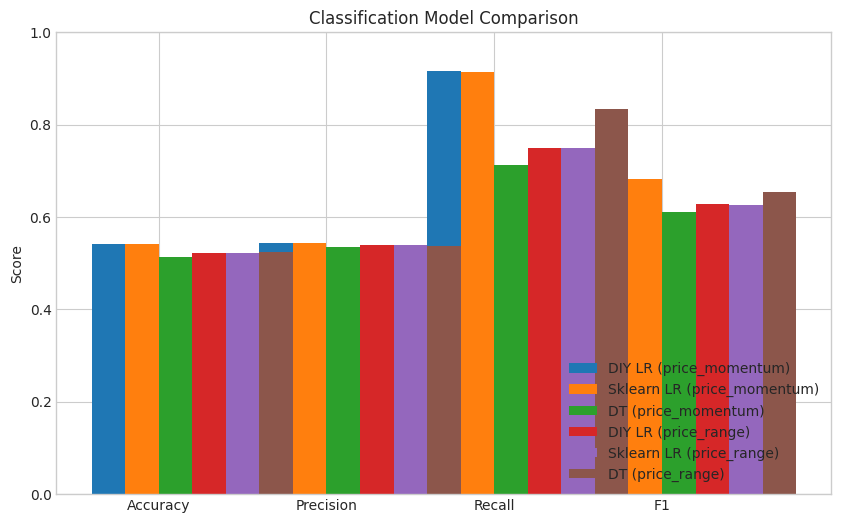

In [7]:
plt.figure(figsize=(10, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(metrics))
width = 0.2

for i, model in enumerate(results_df['Model']):
    plt.bar(x + i*width, results_df[metrics].iloc[i], width, label=model)

plt.xticks(x + width*1.5, metrics)
plt.legend(loc='lower right')
plt.ylabel('Score')
plt.title('Classification Model Comparison')
plt.ylim(0, 1)
plt.show()

## 6. Best Model Analysis

Best model: DIY LR (price_momentum)


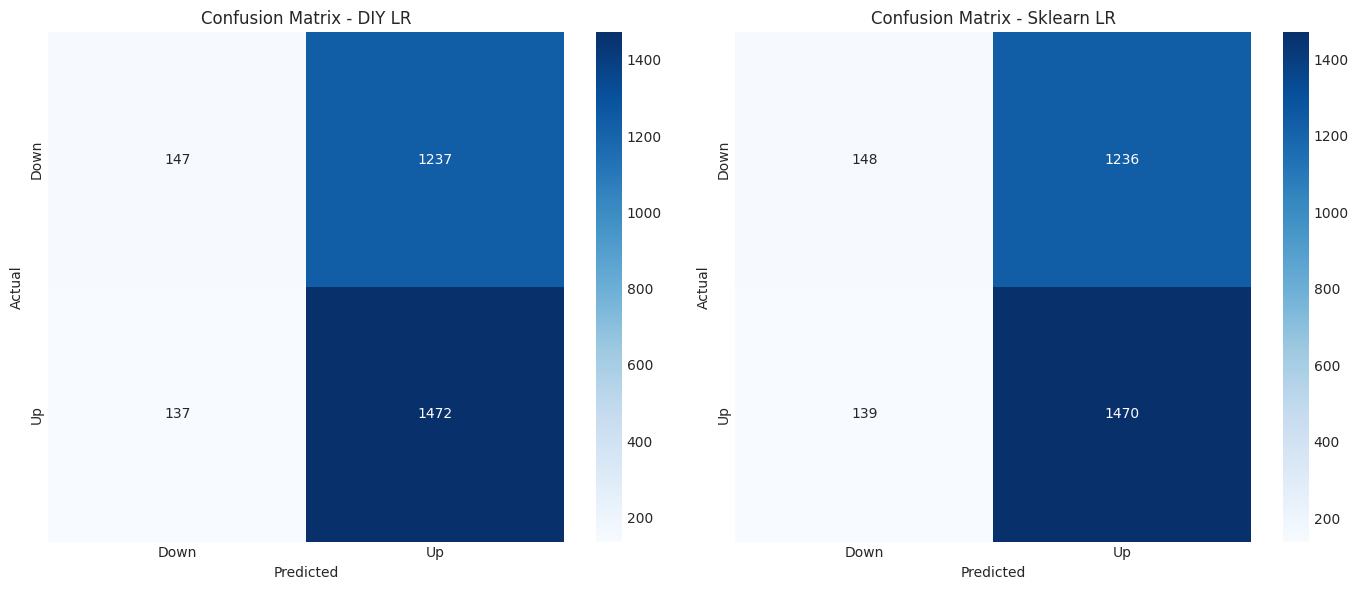


Classification Report (DIY LR):
              precision    recall  f1-score   support

        Down       0.52      0.11      0.18      1384
          Up       0.54      0.91      0.68      1609

    accuracy                           0.54      2993
   macro avg       0.53      0.51      0.43      2993
weighted avg       0.53      0.54      0.45      2993


Classification Report (Sklearn LR):
              precision    recall  f1-score   support

        Down       0.52      0.11      0.18      1384
          Up       0.54      0.91      0.68      1609

    accuracy                           0.54      2993
   macro avg       0.53      0.51      0.43      2993
weighted avg       0.53      0.54      0.45      2993



In [8]:
best_idx = results_df['F1'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
print(f"Best model: {best_model_name}")

set_name = 'price_momentum'
features = feature_sets[set_name]
X = df_sorted[features].values
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_diy = LogisticRegressionGD(learning_rate=0.1, n_iterations=500)
lr_diy.fit(X_train_scaled, y_train)
y_pred_diy = lr_diy.predict(X_test_scaled)

lr_sklearn = LogisticRegression(max_iter=1000, random_state=42)
lr_sklearn.fit(X_train_scaled, y_train)
y_pred_sk = lr_sklearn.predict(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(confusion_matrix(y_test, y_pred_diy), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'], ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix - DIY LR')

sns.heatmap(confusion_matrix(y_test, y_pred_sk), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'], ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix - Sklearn LR')

plt.tight_layout()
plt.show()

print("\nClassification Report (DIY LR):")
print(classification_report(y_test, y_pred_diy, target_names=['Down', 'Up']))
print("\nClassification Report (Sklearn LR):")
print(classification_report(y_test, y_pred_sk, target_names=['Down', 'Up']))

## 7. Hyperparameter Tuning

Best threshold: 0.35 with F1: 0.6994


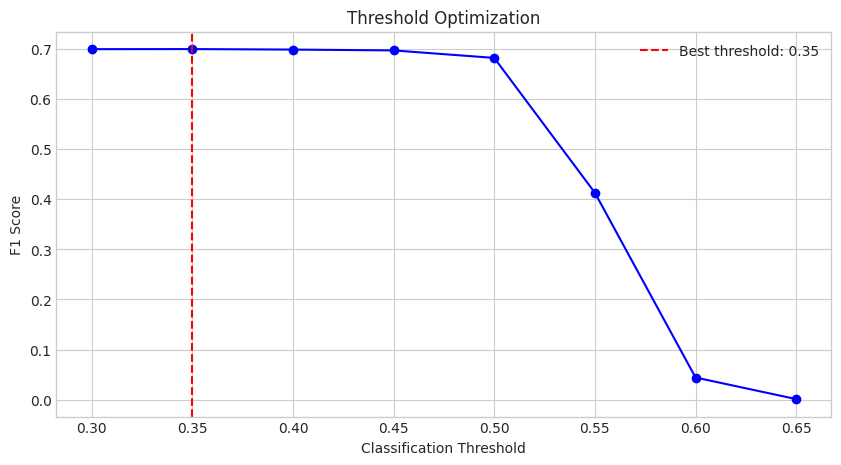

In [9]:
thresholds = np.arange(0.3, 0.7, 0.05)
f1_scores = []

for threshold in thresholds:
    y_pred_thresh = (lr_diy.predict_proba(X_test_scaled) >= threshold).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_thresh))

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)
print(f"Best threshold: {best_threshold:.2f} with F1: {best_f1:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores, 'b-o')
plt.axvline(x=best_threshold, color='r', linestyle='--', label=f'Best threshold: {best_threshold:.2f}')
plt.xlabel('Classification Threshold')
plt.ylabel('F1 Score')
plt.title('Threshold Optimization')
plt.legend()
plt.show()

## 8. Cross-Validation


In [10]:
set_name = 'price_momentum'
features = feature_sets[set_name]
X = df_sorted[features].values
y = df_sorted['Price_Up'].values

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_diy = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    lr_diy = LogisticRegressionGD(learning_rate=0.1, n_iterations=500)
    lr_diy.fit(X_train_scaled, y_train)
    y_pred_diy = lr_diy.predict(X_test_scaled)
    cv_scores_diy.append(f1_score(y_test, y_pred_diy))


print(f"5-Fold CV F1 Scores (DIY): {[f'{s:.4f}' for s in cv_scores_diy]}")
print(f"Mean DIY F1: {np.mean(cv_scores_diy):.4f} (+/- {np.std(cv_scores_diy):.4f})")

# sklearn comparison
cv_scores_sk = []
for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    lr_sklearn = LogisticRegression(max_iter=1000, random_state=42)
    lr_sklearn.fit(X_train_scaled, y_train)
    y_pred_sk = lr_sklearn.predict(X_test_scaled)
    cv_scores_sk.append(f1_score(y_test, y_pred_sk))

print(f"5-Fold CV F1 Scores (Sklearn): {[f'{s:.4f}' for s in cv_scores_sk]}")
print(f"Mean Sklearn F1: {np.mean(cv_scores_sk):.4f} (+/- {np.std(cv_scores_sk):.4f})")


5-Fold CV F1 Scores (DIY): ['0.6976', '0.6817', '0.6830', '0.6997', '0.6810']
Mean DIY F1: 0.6886 (+/- 0.0083)
5-Fold CV F1 Scores (Sklearn): ['0.6974', '0.6811', '0.6833', '0.6994', '0.6810']
Mean Sklearn F1: 0.6884 (+/- 0.0082)


## 9. ROC Curve Analysis 


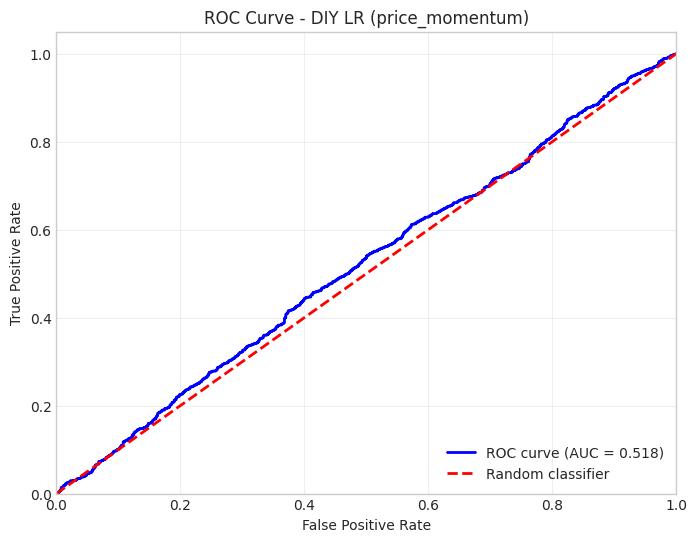

In [11]:
from sklearn.metrics import roc_curve, auc

y_pred_proba = lr_diy.predict_proba(X_test_scaled)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - DIY LR (price_momentum)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

## 10. Conclusions


1. **DIY vs Sklearn Logistic Regression**: The custom gradient descent implementation produces nearly identical predictions to scikit-learn's LogisticRegression, as shown in the comparison table, confusion matrices, and cross-validation results, validating the implementation correctness. Both achieve ~54% accuracy and F1 ~0.68, slightly better than random guessing.

2. **Class Imbalance Impact**: The dataset shows ~54% "Up" and ~46% "Down" days, making it nearly balanced. No aggressive balancing techniques are needed.

3. **Feature Set Performance**: Price momentum features (Daily_Return, Volatility, RSI, MACD_Histogram) outperform range-based features, with F1 scores ~0.68 vs ~0.63.

4. **Model Limitations**: Stock price direction prediction is inherently difficult due to market efficiency. An F1 score of ~0.68 indicates the model captures some signal but is far from perfectly predictive, consistent with weak predictability in efficient markets.

5. **Threshold Optimization**: Adjusting the classification threshold from 0.5 to ~0.35 improves F1 to ~0.70, but gains are marginal. Decision trees with max_depth=10 show similar performance, suggesting the problem has limited learnable structure in these features.